# 🔥 Incendies — Entraînement des modèles ML
**PFE 2026 — Suivi des Catastrophes Naturelles au Maroc**
- **Target :** `fire_risk` (low / medium / high)
- **Dataset :** `data_incendies.csv` — 7 439 lignes
- **Modèles :** Régression Logistique, Arbre de Décision, Random Forest

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

## 1. Chargement des données

(7439, 11)
latitude      0
longitude     0
brightness    0
acq_date      0
confidence    0
frp           0
daynight      0
year          0
month         0
season        0
fire_risk     0
dtype: int64


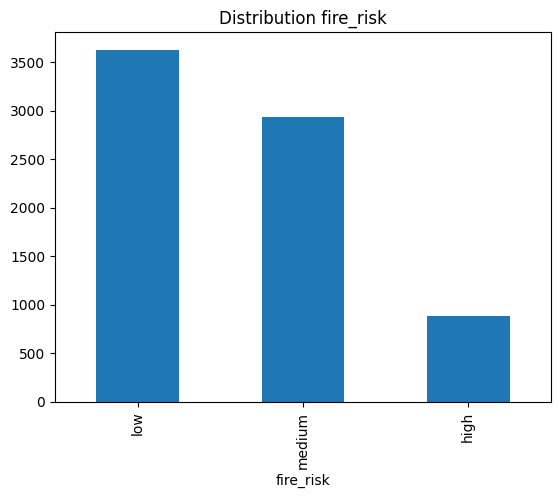

In [65]:
df = pd.read_csv('../data/data_incendies.csv')     #incendies → data_incendies.csv + flood_risk
print(df.shape)
print(df.isnull().sum())
df['fire_risk'].value_counts().plot(kind='bar')
plt.title('Distribution fire_risk')
plt.show()

## 2. Preprocessing

In [70]:


le = LabelEncoder()
date_cols = [col for col in df.columns if 'date' in col.lower()]
df = df.drop(columns=date_cols)

df = df.drop(columns=['brightness', 'frp'], errors='ignore')

categorical_cols = [
    col for col in df.columns
    if (df[col].dtype == 'object' or str(df[col].dtype) == 'string')
    and col != 'fire_risk'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df['fire_risk'] = le.fit_transform(df['fire_risk'])

remaining = df.select_dtypes(include=['object', 'string']).columns.tolist()
if remaining:
    df = df.drop(columns=remaining)

X = df.drop(columns=['fire_risk'])
y = df['fire_risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Colonnes X :", X.columns.tolist())
print("X shape    :", X.shape)

Colonnes X : ['latitude', 'longitude', 'confidence', 'year', 'month']
X shape    : (7439, 5)


## 3. Split Train/Test + SMOTE

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", pd.Series(y_train).value_counts().to_dict())
print("Apres SMOTE :", pd.Series(y_train_res).value_counts().to_dict())


Avant SMOTE : {1: 2903, 2: 2344, 0: 704}
Apres SMOTE : {1: 2903, 2: 2903, 0: 2903}


## 4. Entraînement des 3 modèles

In [68]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained[name] = model
    print(f"{name} : entraine")

Logistic Regression : entraine
Decision Tree : entraine
Random Forest : entraine


## 5. Métriques détaillées

In [69]:
target_names = ['low', 'medium', 'high']
results = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    print(f"\n{'='*50}")
    print(f"Modele   : {name}")
    print(f"Accuracy : {acc:.4f} | F1 : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))



Modele   : Logistic Regression
Accuracy : 0.6277 | F1 : 0.6257
              precision    recall  f1-score   support

         low       0.45      0.81      0.58       176
      medium       0.75      0.72      0.73       726
        high       0.57      0.45      0.50       586

    accuracy                           0.63      1488
   macro avg       0.59      0.66      0.61      1488
weighted avg       0.64      0.63      0.63      1488


Modele   : Decision Tree
Accuracy : 0.6512 | F1 : 0.6479
              precision    recall  f1-score   support

         low       0.50      0.70      0.58       176
      medium       0.73      0.77      0.75       726
        high       0.60      0.49      0.54       586

    accuracy                           0.65      1488
   macro avg       0.61      0.65      0.62      1488
weighted avg       0.65      0.65      0.65      1488


Modele   : Random Forest
Accuracy : 0.6848 | F1 : 0.6812
              precision    recall  f1-score   support

   

## 6. Matrices de confusion

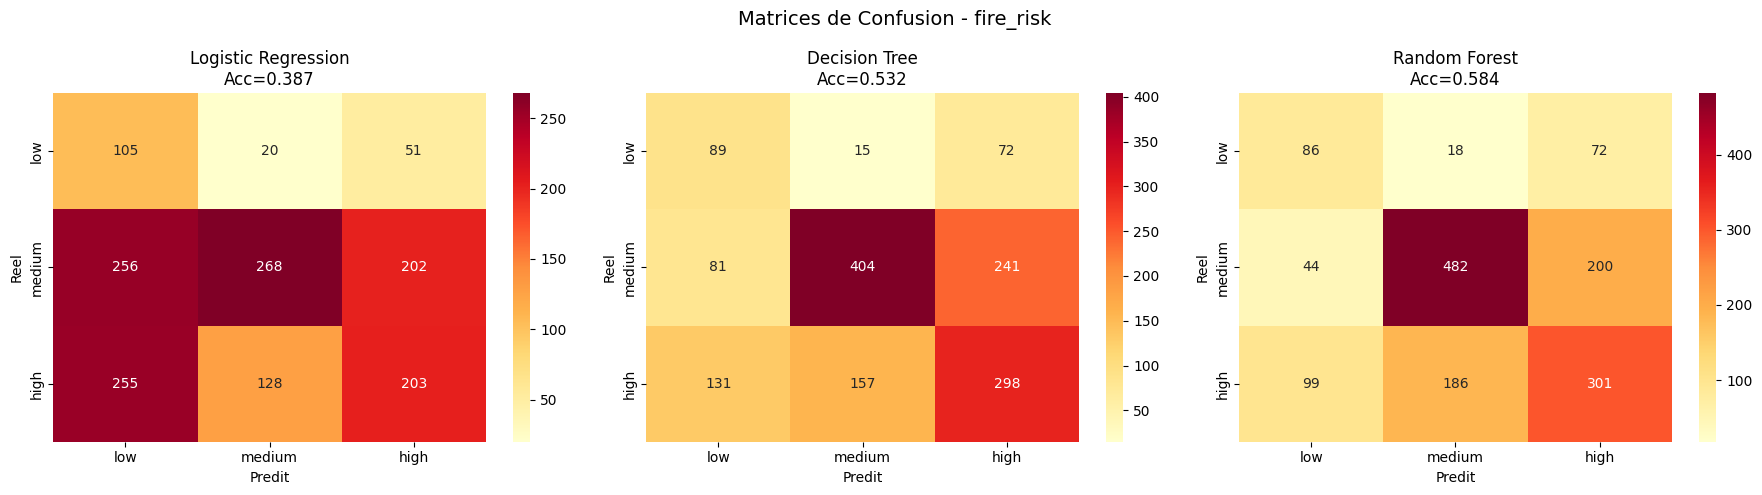

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=target_names,
                yticklabels=target_names, ax=ax)
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f}')
    ax.set_xlabel('Predit')
    ax.set_ylabel('Reel')
plt.suptitle('Matrices de Confusion - fire_risk', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Comparaison des modèles

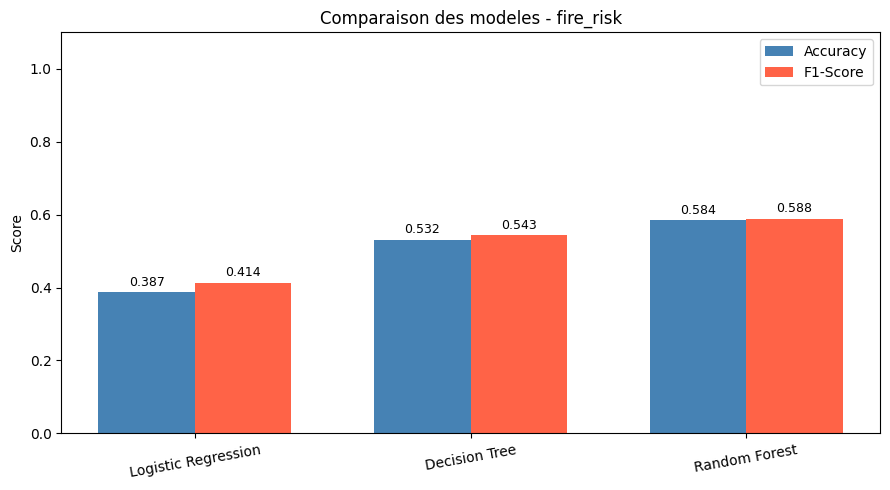


Recapitulatif :
             Modele  Accuracy  F1-Score
      Random Forest  0.584005  0.587887
      Decision Tree  0.531586  0.543009
Logistic Regression  0.387097  0.413805


In [63]:
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
f1s   = [results[n]['f1']       for n in names]
x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1s,  width, label='F1-Score',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modeles - fire_risk')
ax.legend()
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nRecapitulatif :")
recap = pd.DataFrame({'Modele': names, 'Accuracy': accs, 'F1-Score': f1s})
print(recap.sort_values('F1-Score', ascending=False).to_string(index=False))

## 8. Export du modèle choisi (.pkl) (Aprés la décision final)

## 9. Résumé — À envoyer à la coordinatrice

| Modèle | Accuracy | F1-score |
|--------|----------|----------|
| Régression Logistique | | |
| Arbre de Décision | | |
| Random Forest | | |

**Modèle retenu :** _______________